In [1]:
import pandas as pd
import json
import os
import re
import random
import numpy as np
from sklearn.model_selection import train_test_split

def clean_text(text):
    """Заменяем переносы строк и табуляции на пробелы"""
    if isinstance(text, str):
        text = re.sub(r'\n|\r|\t', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    return text

def load_json_texts(filepath, source_type):
    """Загружает тексты из JSON файла по значению поля 'source'"""
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    texts = []
    for item in data:
        if item.get('source') == source_type:
            text = clean_text(item.get('text', ''))
            if len(text.split()) >= 50:
                texts.append(text)
    return texts

# === 1. Загрузка train-kenlm.csv ===
print("1. Загрузка train-kenlm.csv...")
cols = ['text', 'label', 'model'] if 'model' in pd.read_csv('train-kenlm.csv', nrows=0).columns else ['text', 'label']
df1 = pd.read_csv('train-kenlm.csv', usecols=cols)
df1['text'] = df1['text'].fillna('').apply(clean_text)

# Фильтрация по длине
df1['word_count'] = df1['text'].str.split().str.len()
df1 = df1[df1['word_count'] >= 50].drop(columns='word_count')

df1_human = df1[df1['label'] == 'human']
df1_ai = df1[df1['label'] != 'human']

# Фильтрация AI по моделям (>=700 текстов)
if 'model' in df1.columns:
    model_counts = df1_ai['model'].value_counts()
    models_to_keep = model_counts[model_counts >= 700].index
    df1_ai = df1_ai[df1_ai['model'].isin(models_to_keep)]

print(f"  train-kenlm.csv: human={len(df1_human)}, ai={len(df1_ai)}")

# === 2. Загрузка llmtrace_articles.csv ===
print("\n2. Загрузка llmtrace_articles.csv...")
cols = ['text', 'label', 'model'] if 'model' in pd.read_csv('llmtrace_articles.csv', nrows=0).columns else ['text', 'label']
df2 = pd.read_csv('llmtrace_articles.csv', usecols=cols)
df2['text'] = df2['text'].fillna('').apply(clean_text)

df2['word_count'] = df2['text'].str.split().str.len()
df2 = df2[df2['word_count'] >= 50].drop(columns='word_count')

df2_human = df2[df2['label'] == 'human']
df2_ai = df2[df2['label'] != 'human']

if 'model' in df2.columns:
    model_counts = df2_ai['model'].value_counts()
    models_to_keep = model_counts[model_counts >= 700].index
    df2_ai = df2_ai[df2_ai['model'].isin(models_to_keep)]

print(f"  llmtrace_articles.csv: human={len(df2_human)}, ai={len(df2_ai)}")

# === 3. Загрузка llmtrace_stories.csv ===
print("\n3. Загрузка llmtrace_stories.csv...")
cols = ['text', 'label', 'model'] if 'model' in pd.read_csv('llmtrace_stories.csv', nrows=0).columns else ['text', 'label']
df3 = pd.read_csv('llmtrace_stories.csv', usecols=cols)
df3['text'] = df3['text'].fillna('').apply(clean_text)

df3['word_count'] = df3['text'].str.split().str.len()
df3 = df3[df3['word_count'] >= 50].drop(columns='word_count')

df3_human = df3[df3['label'] == 'human']
df3_ai = df3[df3['label'] != 'human']

if 'model' in df3.columns:
    model_counts = df3_ai['model'].value_counts()
    models_to_keep = model_counts[model_counts >= 700].index
    df3_ai = df3_ai[df3_ai['model'].isin(models_to_keep)]

print(f"  llmtrace_stories.csv: human={len(df3_human)}, ai={len(df3_ai)}")

# === 4. Загрузка llmtrace_news.csv ===
print("\n4. Загрузка llmtrace_news.csv...")
cols = ['text', 'label', 'model'] if 'model' in pd.read_csv('llmtrace_news.csv', nrows=0).columns else ['text', 'label']
df4 = pd.read_csv('llmtrace_news.csv', usecols=cols)
df4['text'] = df4['text'].fillna('').apply(clean_text)

df4['word_count'] = df4['text'].str.split().str.len()
df4 = df4[df4['word_count'] >= 50].drop(columns='word_count')

df4_human = df4[df4['label'] == 'human']
df4_ai = df4[df4['label'] != 'human']

if 'model' in df4.columns:
    model_counts = df4_ai['model'].value_counts()
    models_to_keep = model_counts[model_counts >= 700].index
    df4_ai = df4_ai[df4_ai['model'].isin(models_to_keep)]

print(f"  llmtrace_news.csv: human={len(df4_human)}, ai={len(df4_ai)}")

# === 5. Загрузка JSON news ===
print("\n5. Загрузка JSON news...")
base_path = 'ru_hard_dataset'
news_human_json = load_json_texts(os.path.join(base_path, 'news', 'original_news.json'), 'human')
news_ai_json = load_json_texts(os.path.join(base_path, 'news', 'generated_news.json'), 'ai')

print(f"  JSON news: human={len(news_human_json)}, ai={len(news_ai_json)}")

# === 6. Объединение всех данных ===
print("\n6. Объединение данных...")

all_human = []
all_ai = []

# Функция для добавления с ограничением
def add_with_limit(target_list, source_list, limit):
    target_list.extend(source_list[:limit])

# Добавляем из каждого источника
add_with_limit(all_human, df1_human['text'].tolist(), 6000)
add_with_limit(all_ai, df1_ai['text'].tolist(), 6000)

add_with_limit(all_human, df2_human['text'].tolist(), 6000)
add_with_limit(all_ai, df2_ai['text'].tolist(), 6000)

add_with_limit(all_human, df3_human['text'].tolist(), 6000)
add_with_limit(all_ai, df3_ai['text'].tolist(), 6000)

add_with_limit(all_human, df4_human['text'].tolist(), 5040)  # 5040 текстов
add_with_limit(all_ai, df4_ai['text'].tolist(), 5040)

add_with_limit(all_human, news_human_json, 6000)
add_with_limit(all_ai, news_ai_json, 6000)

print(f"\nИтого до балансировки:")
print(f"  Human: {len(all_human)} текстов")
print(f"  AI: {len(all_ai)} текстов")

# === 7. Балансировка ===
n_samples = min(len(all_human), len(all_ai))
print(f"\nБалансировка: берем {n_samples} текстов каждого класса")

if len(all_human) > n_samples:
    all_human = random.sample(all_human, n_samples)
if len(all_ai) > n_samples:
    all_ai = random.sample(all_ai, n_samples)

print(f"\nПосле балансировки:")
print(f"  Human: {len(all_human)} текстов")
print(f"  AI: {len(all_ai)} текстов")

# === 8. Разделение 70/15/15 ===
human_train, human_temp = train_test_split(all_human, test_size=0.3, random_state=42, shuffle=True)
human_val, human_test = train_test_split(human_temp, test_size=0.5, random_state=42, shuffle=True)

ai_train, ai_temp = train_test_split(all_ai, test_size=0.3, random_state=42, shuffle=True)
ai_val, ai_test = train_test_split(ai_temp, test_size=0.5, random_state=42, shuffle=True)

print(f"\nРазделение 70/15/15:")
print(f"  Обучение: human={len(human_train)}, ai={len(ai_train)}, всего={len(human_train)+len(ai_train)}")
print(f"  Валидация: human={len(human_val)}, ai={len(ai_val)}, всего={len(human_val)+len(ai_val)}")
print(f"  Тест: human={len(human_test)}, ai={len(ai_test)}, всего={len(human_test)+len(ai_test)}")

# === 9. Сохранение файлов ===
print("\n7. Сохранение файлов...")

# Удаляем старые файлы
for f in ['train_texts.txt', 'val_human.txt', 'val_ai.txt', 'test_human.txt', 'test_ai.txt']:
    if os.path.exists(f):
        os.remove(f)
        print(f"  Удален {f}")

with open('train_texts.txt', 'w', encoding='utf-8') as f:
    for text in human_train + ai_train:
        f.write(clean_text(text) + '\n')

with open('val_human.txt', 'w', encoding='utf-8') as f:
    for text in human_val:
        f.write(clean_text(text) + '\n')

with open('val_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_val:
        f.write(clean_text(text) + '\n')

with open('test_human.txt', 'w', encoding='utf-8') as f:
    for text in human_test:
        f.write(clean_text(text) + '\n')

with open('test_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_test:
        f.write(clean_text(text) + '\n')

print("\nФайлы сохранены:")
print(f"  train_texts.txt: {len(human_train)+len(ai_train)} текстов")
print(f"  val_human.txt: {len(human_val)} текстов")
print(f"  val_ai.txt: {len(ai_val)} текстов")
print(f"  test_human.txt: {len(human_test)} текстов")
print(f"  test_ai.txt: {len(ai_test)} текстов")# Проверка баланса
print(f"\nПроверка баланса:")
print(f"  Обучение: human/ai = {len(human_train)}/{len(ai_train)} = {len(human_train)/len(ai_train):.2f}")
print(f"  Валидация: human/ai = {len(human_val)}/{len(ai_val)} = {len(human_val)/len(ai_val):.2f}")
print(f"  Тест: human/ai = {len(human_test)}/{len(ai_test)} = {len(human_test)/len(ai_test):.2f}")

# Средняя длина текста на обучении
train_texts_all = human_train + ai_train
train_lengths = [len(text.split()) for text in train_texts_all]
print(f"\nСредняя длина текста в обучающей выборке: {np.mean(train_lengths):.1f} слов")
print(f"  Мин/Макс: {np.min(train_lengths)} / {np.max(train_lengths)}")

# Удаляем старые файлы
for f in ['train_texts.txt', 'val_human.txt', 'val_ai.txt', 'test_human.txt', 'test_ai.txt']:
    if os.path.exists(f):
        os.remove(f)
        print(f"Удален {f}")

# Сохраняем файлы
with open('train_texts.txt', 'w', encoding='utf-8') as f:
    for text in human_train + ai_train:
        f.write(clean_text(text) + '\n')

with open('val_human.txt', 'w', encoding='utf-8') as f:
    for text in human_val:
        f.write(clean_text(text) + '\n')

with open('val_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_val:
        f.write(clean_text(text) + '\n')

with open('test_human.txt', 'w', encoding='utf-8') as f:
    for text in human_test:
        f.write(clean_text(text) + '\n')

with open('test_ai.txt', 'w', encoding='utf-8') as f:
    for text in ai_test:
        f.write(clean_text(text) + '\n')

print("\nФайлы сохранены:")
print(f"  train_texts.txt: {len(human_train)+len(ai_train)} текстов")
print(f"  val_human.txt: {len(human_val)} текстов")
print(f"  val_ai.txt: {len(ai_val)} текстов")
print(f"  test_human.txt: {len(human_test)} текстов")
print(f"  test_ai.txt: {len(ai_test)} текстов")

1. Загрузка train-kenlm.csv...
  train-kenlm.csv: human=7275, ai=23963

2. Загрузка llmtrace_articles.csv...
  llmtrace_articles.csv: human=13958, ai=13216

3. Загрузка llmtrace_stories.csv...
  llmtrace_stories.csv: human=7769, ai=6301

4. Загрузка llmtrace_news.csv...
  llmtrace_news.csv: human=11276, ai=9196

5. Загрузка JSON news...
  JSON news: human=480, ai=480

6. Объединение данных...

Итого до балансировки:
  Human: 23520 текстов
  AI: 23520 текстов

Балансировка: берем 23520 текстов каждого класса

После балансировки:
  Human: 23520 текстов
  AI: 23520 текстов

Разделение 70/15/15:
  Обучение: human=16464, ai=16464, всего=32928
  Валидация: human=3528, ai=3528, всего=7056
  Тест: human=3528, ai=3528, всего=7056

7. Сохранение файлов...
  Удален train_texts.txt
  Удален val_human.txt
  Удален val_ai.txt
  Удален test_human.txt
  Удален test_ai.txt

Файлы сохранены:
  train_texts.txt: 32928 текстов
  val_human.txt: 3528 текстов
  val_ai.txt: 3528 текстов
  test_human.txt: 3528 

In [2]:
import os
import subprocess
import sys
import shutil

print("="*60)
print("ПЕРЕУСТАНОВКА KENLM")
print("="*60)

# 1. Удаляем старые версии
print("\n1. Удаление старых версий...")
!pip uninstall kenlm -y 2>/dev/null
if os.path.exists("kenlm-master"):
    shutil.rmtree("kenlm-master")
    print("  ✓ Удалена папка kenlm-master")

# 2. Устанавливаем зависимости
print("\n2. Установка зависимостей...")
!apt-get update -qq
!apt-get install -y build-essential cmake libboost-all-dev wget

# 3. Скачиваем KenLM
print("\n3. Скачивание KenLM...")
!wget -q -O kenlm.tar.gz https://github.com/kpu/kenlm/archive/master.tar.gz
!tar xzf kenlm.tar.gz
!rm kenlm.tar.gz

# 4. Компилируем
print("\n4. Компиляция KenLM...")
os.chdir("kenlm-master")
!mkdir -p build
os.chdir("build")
!cmake ..
!make -j2

# 5. Устанавливаем Python-обертку
print("\n5. Установка Python-обертки...")
os.chdir("/workspace/cloud/experiments")
!pip install https://github.com/kpu/kenlm/archive/master.zip

# 6. Проверяем
print("\n6. Проверка...")
import kenlm
print("✅ KenLM успешно установлен!")

# 7. Путь к бинарникам
bin_path = os.path.abspath("kenlm-master/build/bin")
print(f"\nБинарники: {bin_path}")
!ls -la {bin_path}/lmplz
!ls -la {bin_path}/build_binary

ПЕРЕУСТАНОВКА KENLM

1. Удаление старых версий...
  ✓ Удалена папка kenlm-master

2. Установка зависимостей...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
build-essential set to manually installed.
The following additional packages will be installed:
  autoconf automake autotools-dev cmake-data cpp-11 dh-elpa-helper
  emacsen-common file g++-11 gcc-11 gcc-11-base gfortran gfortran-11
  ibverbs-providers icu-devtools libarchive13 libasan6 libboost-atomic-dev
  libboost-atomic1.74-dev libboost-atomic1.74.0 libboost-chrono-dev
  libboost-chrono1.74-dev libboost-chrono1.74.0 libboost-container-dev
  libboost-container1.74-dev libboost-container1.74.0 libboost-context-dev
  libboost-context1.74-dev libboost-context1.74.0 libboost-coroutine-dev
  libboost-coroutine1.74-dev libboost-coroutine1.74.0 libboost-date-time-dev
  libboost-date-time1.74-dev libboost-date-time1.74.0 libboo

In [3]:
import os
import subprocess

bin_path = os.path.abspath("kenlm-master/build/bin")
lmplz_path = os.path.join(bin_path, "lmplz")
build_binary_path = os.path.join(bin_path, "build_binary")

print("Обучение KenLM модели...")

!{lmplz_path} -o 3 < train_texts.txt > model.arpa
!{build_binary_path} model.arpa model.binary

!ls -lh model.arpa model.binary

import kenlm
model = kenlm.Model('model.binary')
print("Модель успешно загружена!")

Обучение KenLM модели...
=== 1/5 Counting and sorting n-grams ===
Reading /workspace/cloud/experiments/train_texts.txt
----5---10---15---20---25---30---35---40---45---50---55---60---65---70---75---80---85---90---95--100
****************************************************************************************************
Unigram tokens 9377259 types 892366
=== 2/5 Calculating and sorting adjusted counts ===
Chain sizes: 1:10708392 2:1138847104 3:2135338240
Statistics:
1 892366 D1=0.698837 D2=1.04545 D3+=1.36898
2 5204704 D1=0.852235 D2=1.17255 D3+=1.35253
3 8069731 D1=0.905281 D2=1.43633 D3+=1.53176
Memory estimate for binary LM:
type     MB
probing 279 assuming -p 1.5
probing 312 assuming -r models -p 1.5
trie    135 without quantization
trie     83 assuming -q 8 -b 8 quantization 
trie    125 assuming -a 22 array pointer compression
trie     74 assuming -a 22 -q 8 -b 8 array pointer compression and quantization
=== 3/5 Calculating and sorting initial probabilities ===
Chain sizes: 1:10

In [4]:
def get_perplexity(model, text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return None
    try:
        log_prob = model.score(text)
        words = text.split()
        return 2.0 ** (-log_prob / len(words)) if words else None
    except:
        return None

In [5]:
import numpy as np
with open('val_human.txt', 'r', encoding='utf-8') as f:
    val_human = [line.strip() for line in f.readlines() if line.strip()]

with open('val_ai.txt', 'r', encoding='utf-8') as f:
    val_ai = [line.strip() for line in f.readlines() if line.strip()]

print(f"Валидация: human={len(val_human)}, ai={len(val_ai)}")

val_human_ppl = [get_perplexity(model, text) for text in val_human]
val_human_ppl = [x for x in val_human_ppl if x is not None]

val_ai_ppl = [get_perplexity(model, text) for text in val_ai]
val_ai_ppl = [x for x in val_ai_ppl if x is not None]

print(f"  Среднее ppl human: {np.mean(val_human_ppl):.2f}")
print(f"  Среднее ppl ai: {np.mean(val_ai_ppl):.2f}")

Валидация: human=3528, ai=3528
  Среднее ppl human: 14.58
  Среднее ppl ai: 9.47


Accuracy порог: 10.78 (acc=0.7657)
F1 порог:       11.67 (f1=0.7619)
AUC порог:   10.71 (auc=0.8249)


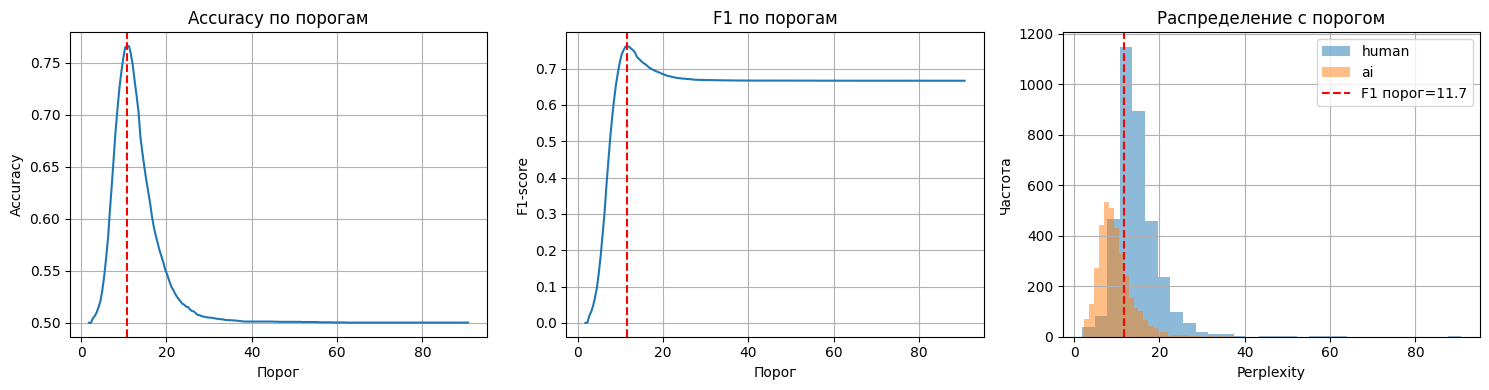

In [6]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

all_ppl = np.array(val_human_ppl + val_ai_ppl)
y_true = [0] * len(val_human_ppl) + [1] * len(val_ai_ppl)

thresholds = np.linspace(min(all_ppl), max(all_ppl), 200)

best_acc = 0
best_thresh_acc = None
acc_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    acc = accuracy_score(y_true, y_pred)
    acc_scores.append(acc)
    if acc > best_acc:
        best_acc = acc
        best_thresh_acc = thresh

best_f1 = 0
best_thresh_f1 = None
f1_scores = []

for thresh in thresholds:
    y_pred = [1 if ppl < thresh else 0 for ppl in all_ppl]
    f1 = f1_score(y_true, y_pred)
    f1_scores.append(f1)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh_f1 = thresh

y_score = -all_ppl
val_auc = roc_auc_score(y_true, y_score)
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
youden = tpr - fpr
best_idx = np.argmax(youden)
best_thresh_youden = -roc_thresholds[best_idx]
best_youden = youden[best_idx]

print(f"Accuracy порог: {best_thresh_acc:.2f} (acc={best_acc:.4f})")
print(f"F1 порог:       {best_thresh_f1:.2f} (f1={best_f1:.4f})")
print(f"AUC порог:   {best_thresh_youden:.2f} (auc={val_auc:.4f})")

# Визуализация
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(thresholds, acc_scores)
plt.axvline(best_thresh_acc, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('Accuracy')
plt.title('Accuracy по порогам')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(thresholds, f1_scores)
plt.axvline(best_thresh_f1, color='red', linestyle='--')
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('F1 по порогам')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.hist(val_human_ppl, bins=30, alpha=0.5, label='human')
plt.hist(val_ai_ppl, bins=30, alpha=0.5, label='ai')
plt.axvline(best_thresh_f1, color='red', linestyle='--', label=f'F1 порог={best_thresh_f1:.1f}')
plt.xlabel('Perplexity')
plt.ylabel('Частота')
plt.title('Распределение с порогом')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [7]:
with open('test_human.txt', 'r', encoding='utf-8') as f:
    test_human = [line.strip() for line in f.readlines() if line.strip()]

with open('test_ai.txt', 'r', encoding='utf-8') as f:
    test_ai = [line.strip() for line in f.readlines() if line.strip()]

print(f"Тест: human={len(test_human)}, ai={len(test_ai)}")

test_human_ppl = [get_perplexity(model, text) for text in test_human]
test_human_ppl = [x for x in test_human_ppl if x is not None]

test_ai_ppl = [get_perplexity(model, text) for text in test_ai]
test_ai_ppl = [x for x in test_ai_ppl if x is not None]

print(f"\nТестовая перплексия:")
print(f"  Human среднее: {np.mean(test_human_ppl):.2f}")
print(f"  Llama среднее: {np.mean(test_ai_ppl):.2f}")

Тест: human=3528, ai=3528

Тестовая перплексия:
  Human среднее: 14.91
  Llama среднее: 9.62


In [13]:
test_all_ppl = np.array(test_human_ppl + test_ai_ppl)
y_test_true = [0] * len(test_human_ppl) + [1] * len(test_ai_ppl)

final_threshold = best_thresh_f1
y_test_pred = [1 if ppl < final_threshold else 0 for ppl in test_all_ppl]

print(f"Используем порог по F1: {final_threshold:.2f}")
print(f"Предсказано machine: {sum(y_test_pred)} из {len(y_test_pred)}")

Используем порог по F1: 11.67
Предсказано machine: 3581 из 7056


In [14]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

test_acc = accuracy_score(y_test_true, y_test_pred)
test_f1 = f1_score(y_test_true, y_test_pred)
test_auc = roc_auc_score(y_test_true, -test_all_ppl)

print(f"Accuracy:  {test_acc:.4f}")
print(f"F1-score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

cm = confusion_matrix(y_test_true, y_test_pred)
print("\nМатрица ошибок:")
print("           Pred human  Pred machine")
print(f"Actual human    {cm[0,0]:5d}      {cm[0,1]:5d}")
print(f"Actual machine  {cm[1,0]:5d}      {cm[1,1]:5d}")

Accuracy:  0.7552
F1-score:  0.7571
ROC-AUC:   0.8228

Матрица ошибок:
           Pred human  Pred machine
Actual human     2638        890
Actual machine    837       2691


In [15]:
print(f"{'Метрика':<12} {'Валидация':>10} {'Тест':>10} {'Разница':>10}")
print("-"*50)
print(f"{'F1-score':<12} {best_f1:>10.4f} {test_f1:>10.4f} {test_f1 - best_f1:>+10.4f}")
print(f"{'Accuracy':<12} {best_acc:>10.4f} {test_acc:>10.4f} {test_acc - best_acc:>+10.4f}")
print(f"{'ROC-AUC':<12} {val_auc:>10.4f} {test_auc:>10.4f} {test_auc - val_auc:>+10.4f}")

Метрика       Валидация       Тест    Разница
--------------------------------------------------
F1-score         0.7619     0.7571    -0.0048
Accuracy         0.7657     0.7552    -0.0105
ROC-AUC          0.8249     0.8228    -0.0021


/tmp/ipykernel_27/810686892.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_to_plot, labels=['human', 'ai'], patch_artist=True)


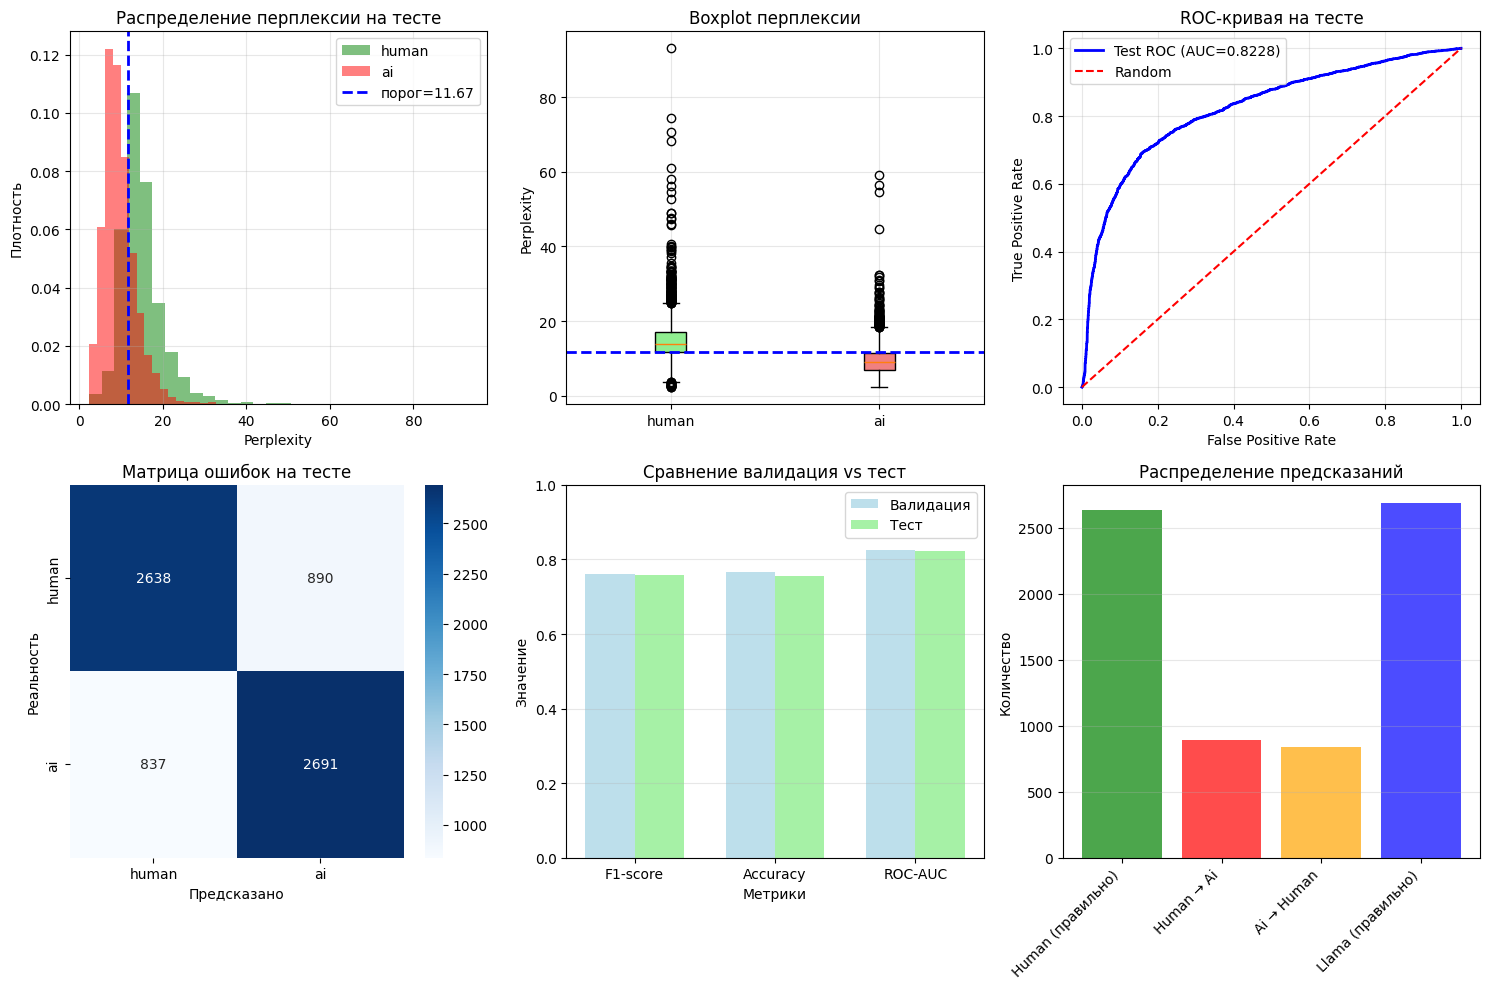


Итоговые метрики на тесте (порог F1=11.67):
  Accuracy: 0.7552
  F1-score: 0.7571
  ROC-AUC:  0.8228


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns

test_machine_ppl = test_ai_ppl
y_test_true = [0]*len(test_human_ppl) + [1]*len(test_machine_ppl)
y_test_score = -np.array(test_human_ppl + test_machine_ppl)

plt.figure(figsize=(15, 10))

# 1. Распределение перплексии на тесте
plt.subplot(2, 3, 1)
plt.hist(test_human_ppl, bins=30, alpha=0.5, label='human', density=True, color='green')
plt.hist(test_machine_ppl, bins=30, alpha=0.5, label='ai', density=True, color='red')
plt.axvline(x=final_threshold, color='blue', linestyle='--', linewidth=2, 
            label=f'порог={final_threshold:.2f}')
plt.xlabel('Perplexity')
plt.ylabel('Плотность')
plt.title('Распределение перплексии на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Boxplot
plt.subplot(2, 3, 2)
data_to_plot = [test_human_ppl, test_machine_ppl]
bp = plt.boxplot(data_to_plot, labels=['human', 'ai'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')
plt.axhline(y=final_threshold, color='blue', linestyle='--', linewidth=2)
plt.ylabel('Perplexity')
plt.title('Boxplot перплексии')
plt.grid(True, alpha=0.3)

# 3. ROC-кривая
plt.subplot(2, 3, 3)
fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_score)
plt.plot(fpr_test, tpr_test, 'b-', linewidth=2, label=f'Test ROC (AUC={test_auc:.4f})')
plt.plot([0,1], [0,1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая на тесте')
plt.legend()
plt.grid(True, alpha=0.3)

# 4. Матрица ошибок
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['human', 'ai'], 
            yticklabels=['human', 'ai'])
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок на тесте')

# 5. Сравнение метрик валидация vs тест
plt.subplot(2, 3, 5)
metrics = ['F1-score', 'Accuracy', 'ROC-AUC']
val_values = [best_f1, best_acc, val_auc]
test_values = [test_f1, test_acc, test_auc]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, val_values, width, label='Валидация', color='lightblue', alpha=0.8)
plt.bar(x + width/2, test_values, width, label='Тест', color='lightgreen', alpha=0.8)
plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение валидация vs тест')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim([0, 1])

# 6. Предсказания по классам
plt.subplot(2, 3, 6)
labels = ['Human (правильно)', 'Human → Ai', 'Ai → Human', 'Llama (правильно)']
values = [cm[0,0], cm[0,1], cm[1,0], cm[1,1]]
colors = ['green', 'red', 'orange', 'blue']
plt.bar(labels, values, color=colors, alpha=0.7)
plt.ylabel('Количество')
plt.title('Распределение предсказаний')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nИтоговые метрики на тесте (порог F1={final_threshold:.2f}):")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  F1-score: {test_f1:.4f}")
print(f"  ROC-AUC:  {test_auc:.4f}")